# All Models — Head-to-Head Comparison

Compares every tabular XGBoost variant and every `LineupGNN` variant on
the same target (`xg_team1_minus_team2_per_30`), the **same row subset**,
and the **same train / test split**.

The base axes are a **2 × 2 design** (kind × opponent), and each track
adds an orthogonal **feature-block axis**:

| axis | levels |
|---|---|
| personnel kind | raw positions · per-season archetypes |
| opponent in view | ego only · matchup (opponent included) |
| tabular features | base · **+ per-season stats** (10-D / slot) |
| graph features | label only · **+ template (x, y)** · **+ per-season stats** |

That gives 4 × 2 tabular variants + 4 × 3 graph variants = **20 models**.
See `models.comparison.MODEL_KEYS` for the full list.

Shared partitions (produced by `scripts.build_train_test_split`):
match-blocked 80 / 20 with `seed=0`, saved to
`data/processed/{train,test}_snapshots.parquet`. Every match's home and
away focal-team rows always land in the same partition, and the filter
`features.snapshots.filter_buildable_snapshots` runs first so the rows
are identical to what the GNN dataset consumes (~73.6 k rows total →
~59.1 k train / ~14.5 k test). NaN archetypes are kept in both pipelines:
XGBoost encodes them as the `"MISSING"` category and the GNN's archetype
vocab includes a `"MISSING"` token. Tabular `+stats` variants look up
each slot's `(player_id, season)` and append the 10-D behavioral vector
(see `archetypes.season_stats`); GNN `+stats` mixes the same vector into
the node embedding *and* adds 4 stat-diff edge features.

Evaluation:

- **Tabular**: `xgb.XGBRegressor` fit on the train parquet, predicted on
  the test parquet. Metrics computed once against the test set.
- **GNN**: trained on the train parquet via `scripts.train_gnn`; each
  epoch evaluates against the test parquet. Best-epoch metrics + test
  predictions are read from `artifacts/gnn_<kind>_<mode>[_coords|_stats]/`.

Caveat: this matches row sets and validation matches, but the GNN gets a
mild advantage from peeking at the test loss every epoch and picking the
best-test checkpoint, while the tabular fit is a single fixed-budget
XGBoost. Add a small inner validation slice if you want that gap closed.

Plotting helpers live in `models.comparison`; this notebook stays thin.


In [1]:
from __future__ import annotations
import sys
from pathlib import Path

HERE = Path.cwd()
ROOT = HERE
while ROOT != ROOT.parent and not (ROOT / 'configs' / 'config.yaml').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from models.comparison import (
    MODEL_KEYS,
    ablation_deltas,
    build_summary_table,
    load_gnn_results,
    load_tabular_results,
    plot_metric_bars,
    plot_pred_vs_target_grid,
    plot_residual_hists,
)

pd.set_option('display.width', 220)
pd.set_option('display.max_columns', 30)

ARTIFACTS = ROOT / 'artifacts'
TRAIN = ROOT / 'data' / 'processed' / 'train_snapshots.parquet'
TEST  = ROOT / 'data' / 'processed' / 'test_snapshots.parquet'
train_df = pd.read_parquet(TRAIN)
test_df  = pd.read_parquet(TEST)
print(f'train: {len(train_df):,} rows / {train_df["match_id"].nunique():,} matches')
print(f'test:  {len(test_df):,} rows / {test_df["match_id"].nunique():,} matches')

train: 59,096 rows / 4,344 matches
test:  14,538 rows / 1,086 matches


## Load results

Fits each tabular model on the train parquet and predicts on the test
parquet (no CV — one fit, one held-out evaluation). Loads GNN training
logs + best-epoch test predictions from `artifacts/`. Models with no log
file are silently skipped — train them with
`python -m scripts.train_gnn --kind <k> --mode <m>` to bring them in.

In [2]:
tab_results = load_tabular_results(train_df, test_df)
gnn_results = load_gnn_results(ARTIFACTS)

available = list(tab_results) + list(gnn_results)
missing = [k for k in MODEL_KEYS if k not in available]
print(f'loaded {len(available)} models: {available}')
if missing:
    print(f'missing: {missing}')

loaded 20 models: ['tab_pos_ego', 'tab_pos_matchup', 'tab_arch_ego', 'tab_arch_matchup', 'tab_pos_ego_stats', 'tab_pos_matchup_stats', 'tab_arch_ego_stats', 'tab_arch_matchup_stats', 'gnn_position_single', 'gnn_archetype_single', 'gnn_position_paired', 'gnn_archetype_paired', 'gnn_position_single_coords', 'gnn_archetype_single_coords', 'gnn_position_paired_coords', 'gnn_archetype_paired_coords', 'gnn_position_single_stats', 'gnn_archetype_single_stats', 'gnn_position_paired_stats', 'gnn_archetype_paired_stats']


## Unified summary table

Every row's metrics come from predictions on the shared held-out test
set. Tabular rows are the single train-fit / test-predict pass; GNN
rows are the best-epoch test metrics from training.

In [3]:
summary = build_summary_table(tab_results, gnn_results)
summary.round(4)

,key,class,kind,opponent,MAE,RMSE,R²,sign acc,eval
model,,,,,,,,,
tab · pos · ego,tab_pos_ego,tabular,position,ego,0.5594,0.9800,0.0116,0.5490,train fit / test predict
tab · pos · matchup,tab_pos_matchup,tabular,position,matchup,0.5680,0.9887,-0.0060,0.5323,train fit / test predict
tab · arch · ego,tab_arch_ego,tabular,archetype,ego,0.5826,0.9873,-0.0032,0.5609,train fit / test predict
tab · arch · matchup,tab_arch_matchup,tabular,archetype,matchup,0.5847,0.9913,-0.0114,0.5780,train fit / test predict
tab · pos · ego · stats,tab_pos_ego_stats,tabular,position,ego,0.5812,0.9782,0.0151,0.5794,train fit / test predict
tab · pos · matchup · stats,tab_pos_matchup_stats,tabular,position,matchup,0.5651,0.9575,0.0564,0.6133,train fit / test predict
tab · arch · ego · stats,tab_arch_ego_stats,tabular,archetype,ego,0.5801,0.9754,0.0207,0.5766,train fit / test predict
tab · arch · matchup · stats,tab_arch_matchup_stats,tabular,archetype,matchup,0.5662,0.9583,0.0548,0.6119,train fit / test predict
gnn · pos · ego,gnn_position_single,graph,position,ego,0.5543,0.9831,0.0052,0.4390,best-of-21 test eval


## Headline metric comparison

Bars colored by `(kind, opponent)` corner; lighter shade is the tabular
model, darker shade is its GNN counterpart at the same corner. All
metrics on the shared held-out test set.

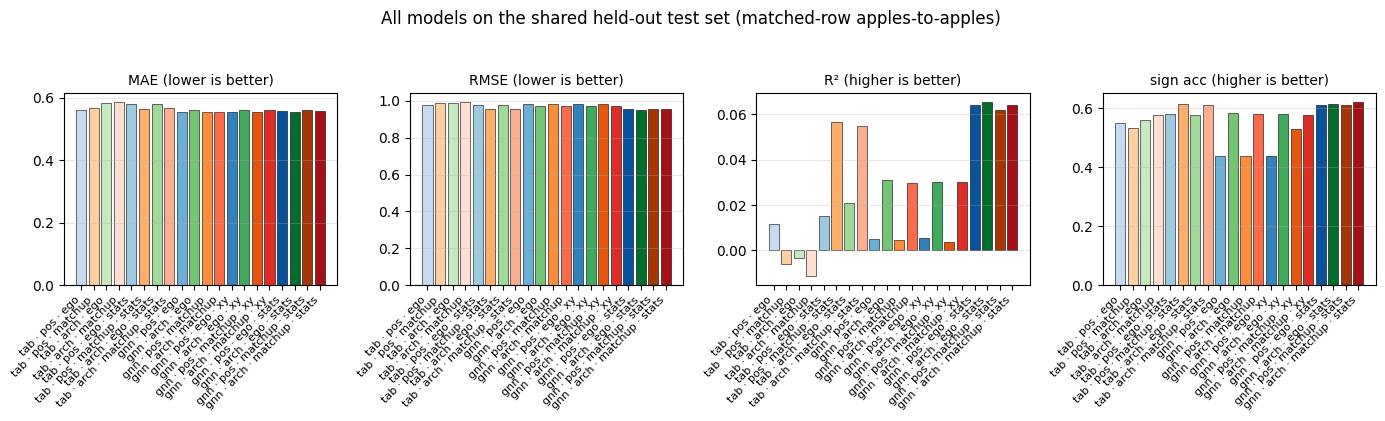

In [4]:
fig = plot_metric_bars(summary); plt.show()

## Predictions vs targets (held-out test set)

Both pipelines predict on the exact same ~14.5k test rows. Top row:
tabular (XGBoost) predictions. Bottom row: GNN best-epoch test
predictions. Columns are the `(kind, opponent)` corners. Pearson `r`
summarises rank-consistency between predictions and observed
differentials.

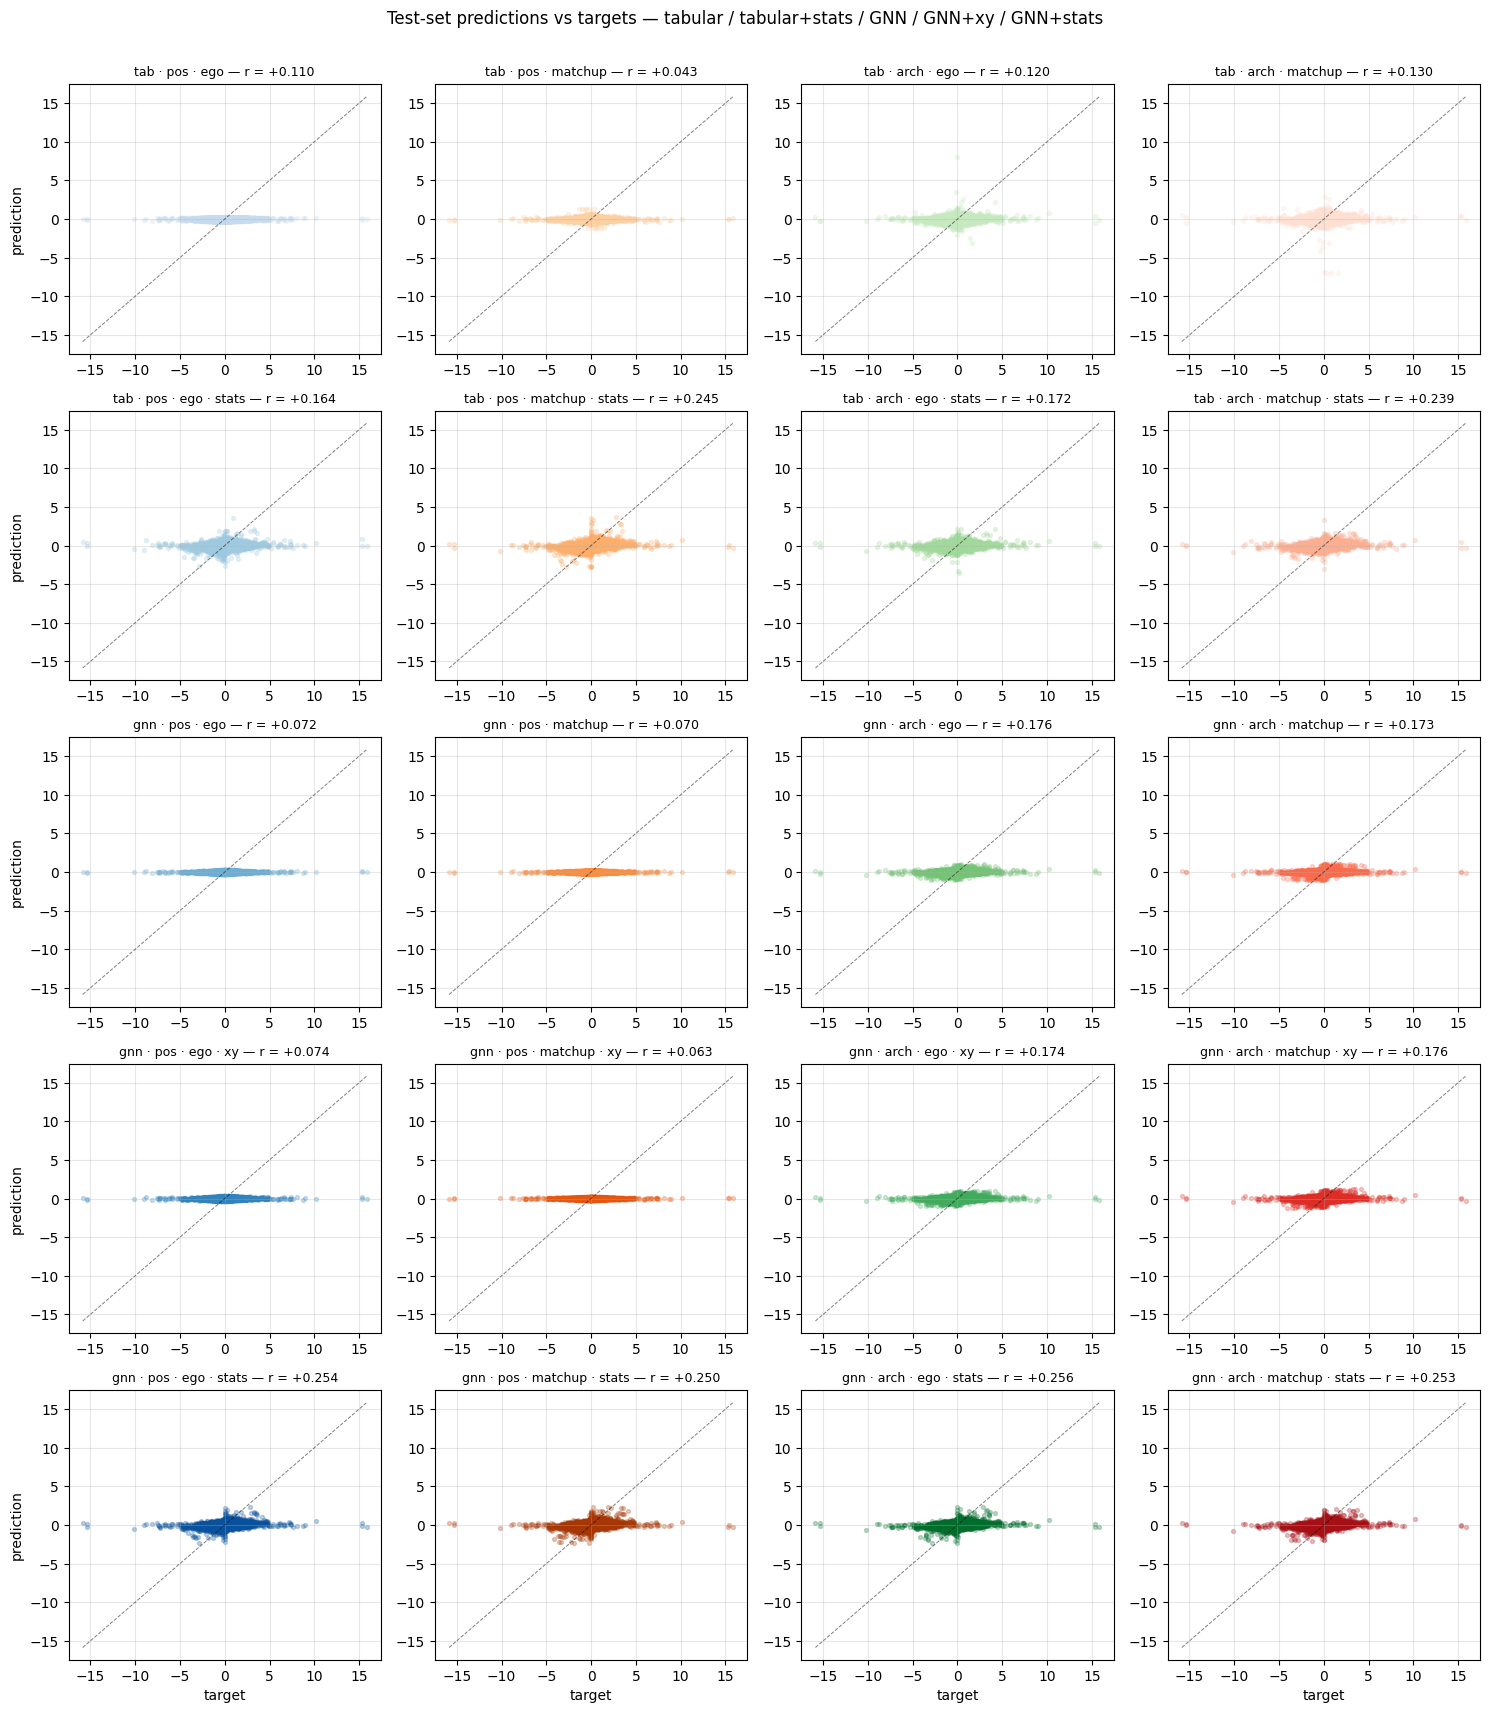

In [5]:
fig = plot_pred_vs_target_grid(tab_results, gnn_results); plt.show()

## Residual distributions (held-out test set)

`pred − target` on the shared test set for each model. The mean (μ)
flags systematic bias; the spread (σ) is an MSE-free read on how
concentrated the errors are.

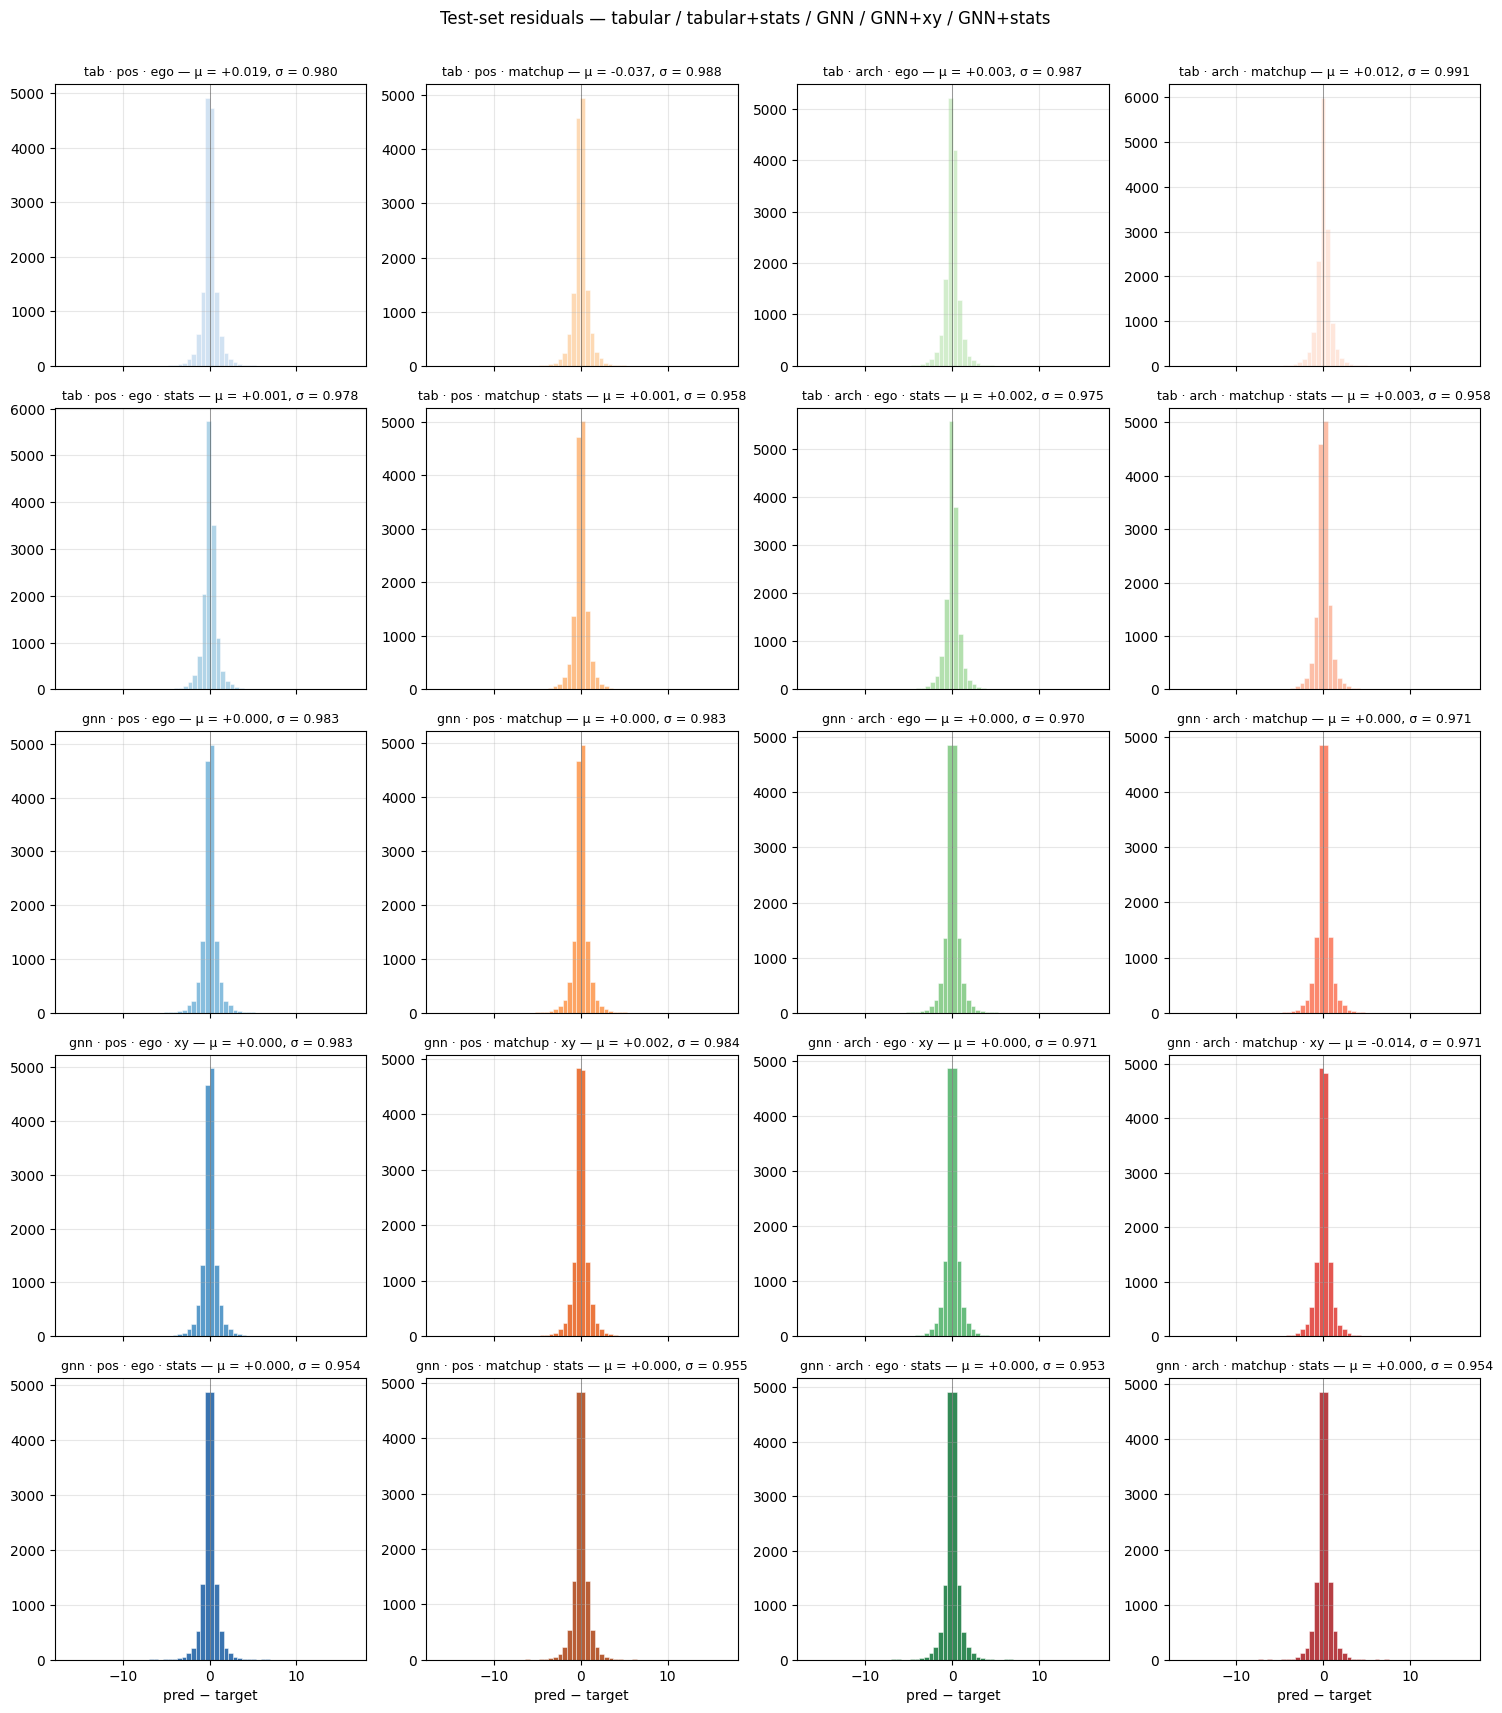

In [6]:
fig = plot_residual_hists(tab_results, gnn_results); plt.show()

## Pairwise ablation deltas

Each row isolates one design axis at one fixed corner of the other two
axes. `Δ MAE` and `Δ RMSE` are negative when the second model (the `to`
column) is better; `Δ R²` and `Δ sign acc` are positive when better.

Three axes:

- **tabular → graph**: does the graph architecture add signal at each `(kind, opponent)` corner?
- **position → archetype**: does archetype enrichment help, holding model class + opponent?
- **ego → matchup**: does including the opponent help, holding model class + kind?

In [7]:
ablation_deltas(summary)

,axis,comparison,from,to,Δ MAE,Δ RMSE,Δ R²,Δ sign acc
0,tabular → graph,pos / ego,tab · pos · ego,gnn · pos · ego,-0.0051,0.0032,-0.0064,-0.1100
1,tabular → graph,pos / matchup,tab · pos · matchup,gnn · pos · matchup,-0.0146,-0.0052,0.0106,-0.0955
2,tabular → graph,arch / ego,tab · arch · ego,gnn · arch · ego,-0.0222,-0.0169,0.0340,0.0231
3,tabular → graph,arch / matchup,tab · arch · matchup,gnn · arch · matchup,-0.0296,-0.0205,0.0413,0.0018
4,position → archetype,tabular / ego,tab · pos · ego,tab · arch · ego,0.0232,0.0073,-0.0148,0.0118
5,position → archetype,tabular / matchup,tab · pos · matchup,tab · arch · matchup,0.0167,0.0026,-0.0054,0.0458
6,position → archetype,graph / ego,gnn · pos · ego,gnn · arch · ego,0.0061,-0.0128,0.0256,0.1449
7,position → archetype,graph / matchup,gnn · pos · matchup,gnn · arch · matchup,0.0017,-0.0126,0.0254,0.1430
8,ego → matchup,tabular / pos,tab · pos · ego,tab · pos · matchup,0.0086,0.0087,-0.0177,-0.0168
9,ego → matchup,tabular / arch,tab · arch · ego,tab · arch · matchup,0.0021,0.0040,-0.0082,0.0172
